## Import data

In [52]:
# import data crime
import pandas as pd
dataset = pd.read_csv('Community_Crime_Statistics_20240907.csv')
dataset.head()

,Community,Category,Crime Count,Year,Month
0,01B,Assault (Non-domestic),1,2022,11
1,01B,Break & Enter - Commercial,1,2019,6
2,01B,Break & Enter - Commercial,1,2019,8
3,01B,Break & Enter - Commercial,2,2020,3
4,01B,Break & Enter - Commercial,2,2020,7


## EDA

In [64]:
# let`s start with EDA

import seaborn as sns
import matplotlib.pyplot as plt

# check the shape of the dataset
print(dataset.shape)


(67595, 5)


In [65]:
# check the columns of the dataset
print(dataset.columns)

Index(['Community', 'Category', 'Crime Count', 'Year', 'Month'], dtype='object')


In [66]:
# check the data types of the columns
print(dataset.dtypes)

Community      object
Category       object
Crime Count     int64
Year            int64
Month           int64
dtype: object


In [67]:
# years
dataset['Year'].unique()

#subsetting the data
dataset = dataset[dataset['Year']!= 2024]

In [68]:
dataset['Year'].unique()

array([2022, 2019, 2020, 2023, 2018, 2021], dtype=int64)

In [69]:
# check the missing values
print(dataset.isnull().sum())

Community      0
Category       0
Crime Count    0
Year           0
Month          0
dtype: int64


In [59]:
# check the unique values in the dataset
print(dataset.nunique())

Community      297
Category         9
Crime Count     77
Year             6
Month           12
dtype: int64


In [70]:
# check the summary statistics of the dataset
dataset.describe()

,Crime Count,Year,Month
count,67595.000000,67595.000000,67595.000000
mean,2.887995,2020.464916,6.545144
std,3.711679,1.714432,3.419915
min,1.000000,2018.000000,1.000000
25%,1.000000,2019.000000,4.000000
50%,2.000000,2020.000000,7.000000
75%,3.000000,2022.000000,9.000000
max,111.000000,2023.000000,12.000000


In [71]:
# check the correlation of the dataset
correlation = dataset.select_dtypes(include=['number']).corr()
print(correlation)

             Crime Count      Year     Month
Crime Count     1.000000 -0.049778 -0.003378
Year           -0.049778  1.000000 -0.013592
Month          -0.003378 -0.013592  1.000000


In [72]:
# now the correlation for each community
correlation_by_community = dataset.groupby('Community').apply(lambda x: x.select_dtypes(include=['number']).corr())
print(correlation_by_community)



                       Crime Count      Year     Month
Community                                             
01B       Crime Count     1.000000 -0.036460 -0.131577
          Year           -0.036460  1.000000  0.388628
          Month          -0.131577  0.388628  1.000000
01F       Crime Count          NaN       NaN       NaN
          Year                 NaN  1.000000 -0.298180
...                            ...       ...       ...
WOODLANDS Year           -0.067824  1.000000 -0.010102
          Month          -0.120261 -0.010102  1.000000
YORKVILLE Crime Count     1.000000 -0.258812  0.228494
          Year           -0.258812  1.000000 -0.029869
          Month           0.228494 -0.029869  1.000000

[891 rows x 3 columns]


<Axes: xlabel='Month', ylabel='Crime Count'>

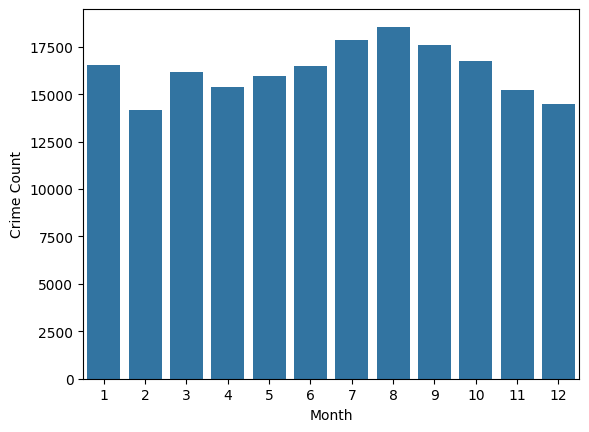

In [73]:
# check the distribution of the target variable by Month
#group by month and sum the crime count
crime_by_month =  dataset.groupby('Month')['Crime Count'].sum().reset_index()
sns.barplot(data=crime_by_month, x='Month', y='Crime Count')


<Axes: xlabel='Month', ylabel='Crime Count'>

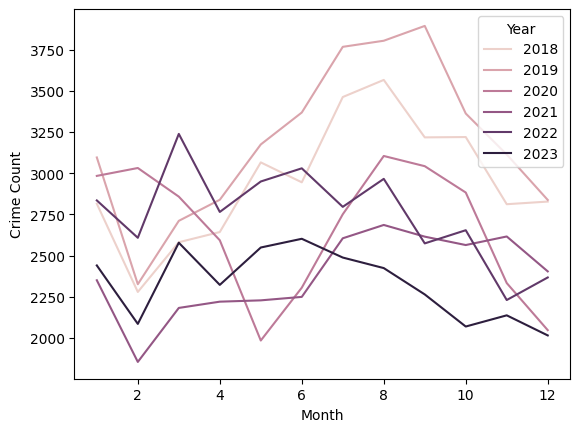

In [74]:
# see crime_by_month perg year
crime_by_month_year = dataset.groupby(['Year','Month'])['Crime Count'].sum().reset_index()
sns.lineplot(data=crime_by_month_year, x='Month', y='Crime Count', hue='Year')  #hue is used to differentiate the years



   Year  Crime Count
0  2018        35437
1  2019        38299
2  2020        31918
3  2021        28573
4  2022        33014
5  2023        27973


<Axes: xlabel='Year', ylabel='Crime Count'>

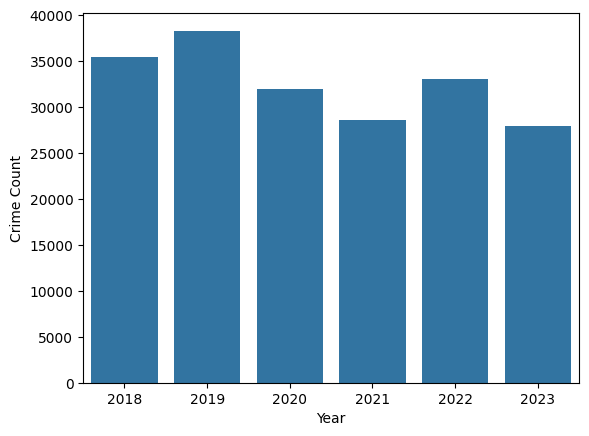

In [75]:
# check the distribution of the target variable by Year
#group Crime Count by year
yearly_data = dataset.groupby('Year')['Crime Count'].sum().reset_index()
print(yearly_data)

#plot the distribution of the target variable by Year
sns.barplot(data=yearly_data, x='Year', y='Crime Count')

#sns.histplot(data=yearly_data, x='Year', y='Crime Count')


## Timeseries Object

In [78]:
# Build time series object
#convert the date to datetime
dataset['Date'] = (dataset['Year'].astype(str) + '-' + dataset['Month'].astype(str) + '-01') #convert to datetime
dataset['Date'].head()



0    2022-11-01
1     2019-6-01
2     2019-8-01
3     2020-3-01
4     2020-7-01
Name: Date, dtype: object